Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipython-input-1442945056.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-1442945056.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

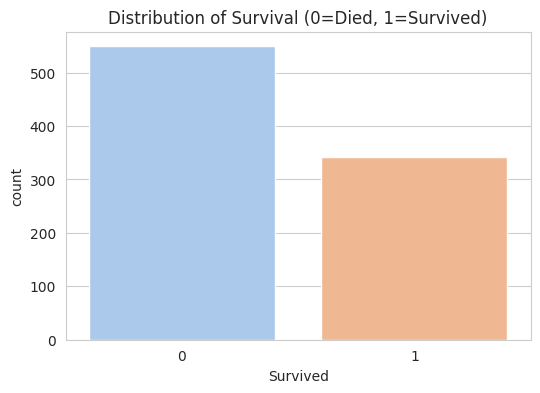

/tmp/ipython-input-1442945056.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='coolwarm')


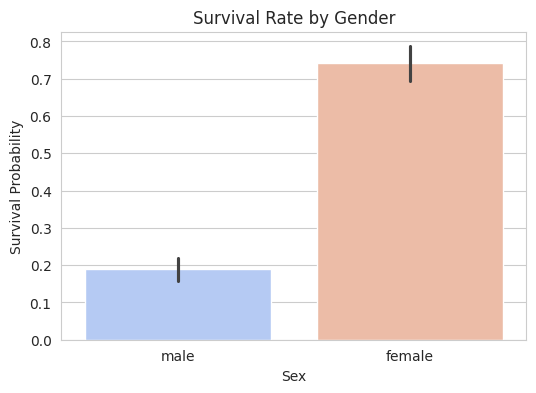

/tmp/ipython-input-1442945056.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='viridis')


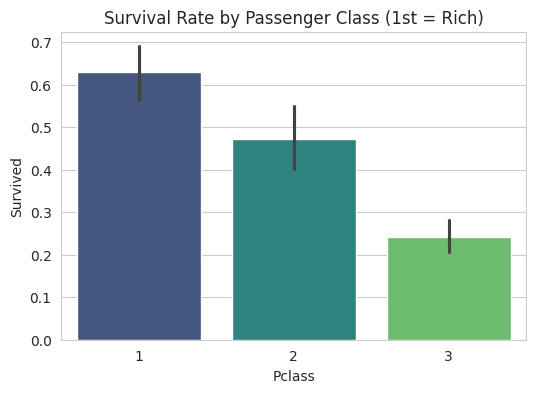

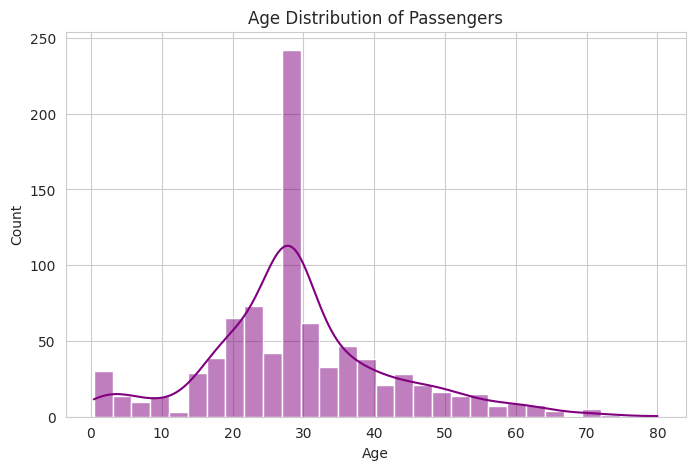

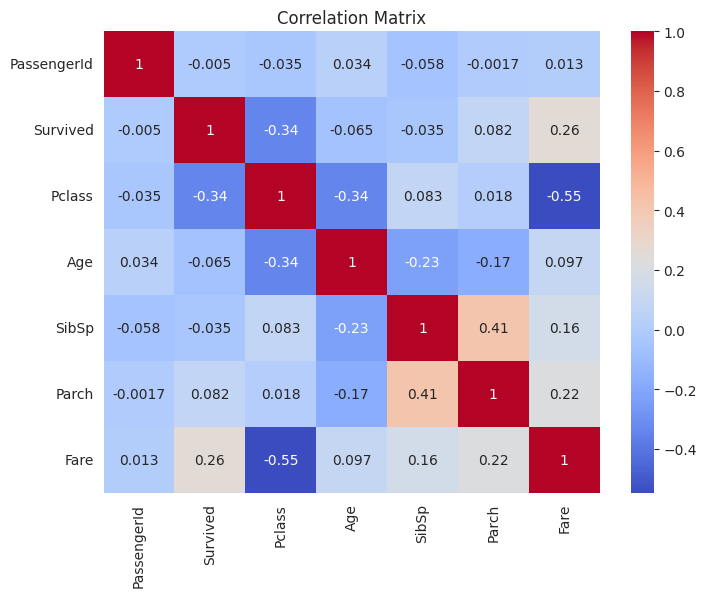

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data
# We use the 'train.csv' because it has the 'Survived' column (the answer key)
df = pd.read_csv('train.csv')

# --- PART 1: DATA CLEANING ---
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fix Missing Values:
# Fill missing 'Age' with the median age (a safe bet)
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing 'Embarked' with the most common port (mode)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop 'Cabin' because too many are missing (it's hard to fix)
df.drop(columns=['Cabin'], inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())


# --- PART 2: EXPLORATORY DATA ANALYSIS (EDA) ---

# Set the visual style
sns.set_style("whitegrid")

# 1. Who Survived? (Target Variable)
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='pastel')
plt.title('Distribution of Survival (0=Died, 1=Survived)')
plt.show()

# 2. Survival by Gender (Categorical vs Categorical)
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=df, palette='coolwarm')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Probability')
plt.show()

# 3. Survival by Class (Rich vs Poor)
plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=df, palette='viridis')
plt.title('Survival Rate by Passenger Class (1st = Rich)')
plt.show()

# 4. Age Distribution (Continuous Variable)
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='purple')
plt.title('Age Distribution of Passengers')
plt.show()

# 5. Correlation Heatmap (Relationships between variables)
# We only select numeric columns for correlation
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()